In [2]:
import sys
import os
from pathlib import Path

ROOT = Path().resolve().parent.parent
sys.path.insert(0, str(ROOT))

print("Añadido al path:", ROOT)

Añadido al path: C:\Users\oscar\AndroidStudioProjects\c2526-R2


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

pd.set_option("display.max_columns", None)

In [6]:
import io
import os
import matplotlib.pyplot as plt

from src.utils.funciones_minio import crear_cliente_minio, bajar_minio
from src.config import PATH_PRIMARIOS_LIMPIO

OBJ_VIVIENDAS_VENTA = "viviendas_venta.parquet"
OBJ_VIVIENDAS_ALQUILER = "viviendas_alquiler.parquet"


In [7]:
client = crear_cliente_minio()

In [26]:
df_venta = bajar_minio(client, PATH_PRIMARIOS_LIMPIO, OBJ_VIVIENDAS_VENTA)
if not isinstance(df_venta, pd.DataFrame):
        df_venta = pd.read_parquet(io.BytesIO(df_venta))
df_alquiler = bajar_minio(client, PATH_PRIMARIOS_LIMPIO, OBJ_VIVIENDAS_ALQUILER)
if not isinstance(df_alquiler, pd.DataFrame):
        df_alquiler = pd.read_parquet(io.BytesIO(df_alquiler))

In [9]:
print(df_venta.columns)
print(df_alquiler.columns)

Index(['id', 'Nombre', 'Barrio', 'Distrito', 'Calle', 'Precio', 'Superficie',
       'Num_habitaciones', 'Banyos', 'Planta', 'Ventanas', 'Ascensor',
       'Terraza', 'Balcon', 'Equipamiento', 'Cocina', 'Orientacion', 'Consumo',
       'Descripcion', 'Anuncia', 'Url', 'Direccion', 'lat', 'lon', 'Tipo_OSM',
       'Tipo_Via'],
      dtype='str')
Index(['id', 'Nombre', 'Barrio', 'Distrito', 'Calle', 'Precio', 'Superficie',
       'Num_habitaciones', 'Banyos', 'Planta', 'Ventanas', 'Ascensor',
       'Terraza', 'Balcon', 'Equipamiento', 'Cocina', 'Orientacion', 'Consumo',
       'Descripcion', 'Anuncia', 'Url', 'Direccion', 'lat', 'lon', 'Tipo_OSM',
       'Tipo_Via'],
      dtype='str')


In [37]:
df_venta["Precio/Superficie"] = df_venta["Precio"] / df_venta["Superficie"]
df_alquiler["Precio/Superficie"] = df_alquiler["Precio"] / df_alquiler["Superficie"]


In [14]:
def resumen_estadistico(df, nombre):
    print(f"\n===== {nombre.upper()} =====")
    print(df[["Precio", "Superficie", "Precio/Superficie"]].describe())
    
    print("\nAsimetría:")
    print(df[["Precio", "Superficie", "Precio/Superficie"]].skew())
    
    print("\nCurtosis:")
    print(df[["Precio", "Superficie", "Precio/Superficie"]].kurt())

resumen_estadistico(df_venta, "ventas")
resumen_estadistico(df_alquiler, "alquiler")


===== VENTAS =====
             Precio    Superficie  Precio/Superficie
count  1.184500e+04  11845.000000       11845.000000
mean   1.030501e+06    129.079021        7314.781240
std    1.263072e+06    160.975405        3825.834921
min    4.700000e+04     11.000000         140.363520
25%    3.190000e+05     68.000000        4300.000000
50%    6.100000e+05     92.000000        6601.941748
75%    1.272500e+06    146.000000        9430.379747
max    2.300000e+07  12489.000000       43888.888889

Asimetría:
Precio                4.349285
Superficie           39.869332
Precio/Superficie     1.205115
dtype: float64

Curtosis:
Precio                 33.544609
Superficie           2943.355304
Precio/Superficie       2.579689
dtype: float64

===== ALQUILER =====
             Precio   Superficie  Precio/Superficie
count   9909.000000  9909.000000        9909.000000
mean    2386.825714    88.992936          28.758055
std     1839.934265    67.501022          12.725217
min      575.000000    10.00

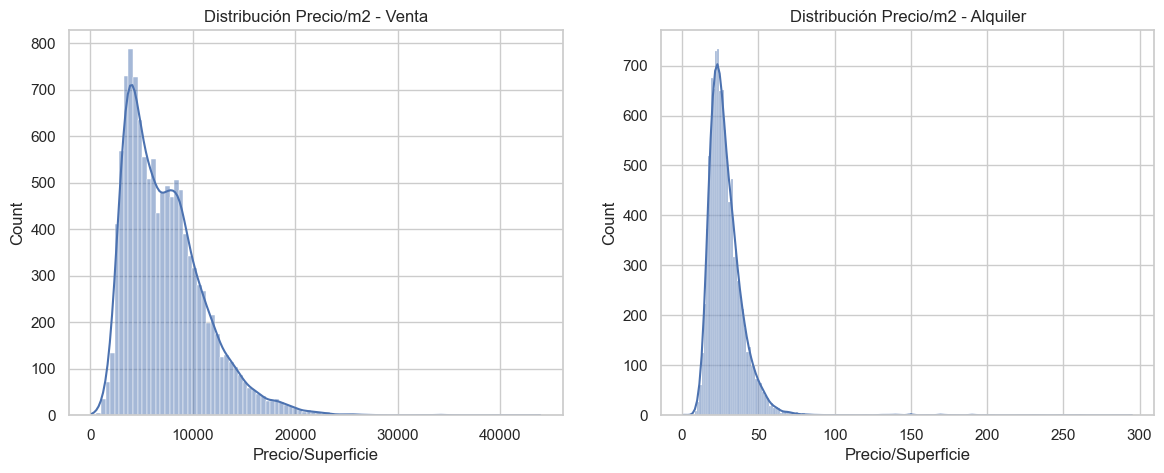

In [15]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(df_venta["Precio/Superficie"], kde=True, ax=axes[0])
axes[0].set_title("Distribución Precio/m2 - Venta")

sns.histplot(df_alquiler["Precio/Superficie"], kde=True, ax=axes[1])
axes[1].set_title("Distribución Precio/m2 - Alquiler")

plt.show()

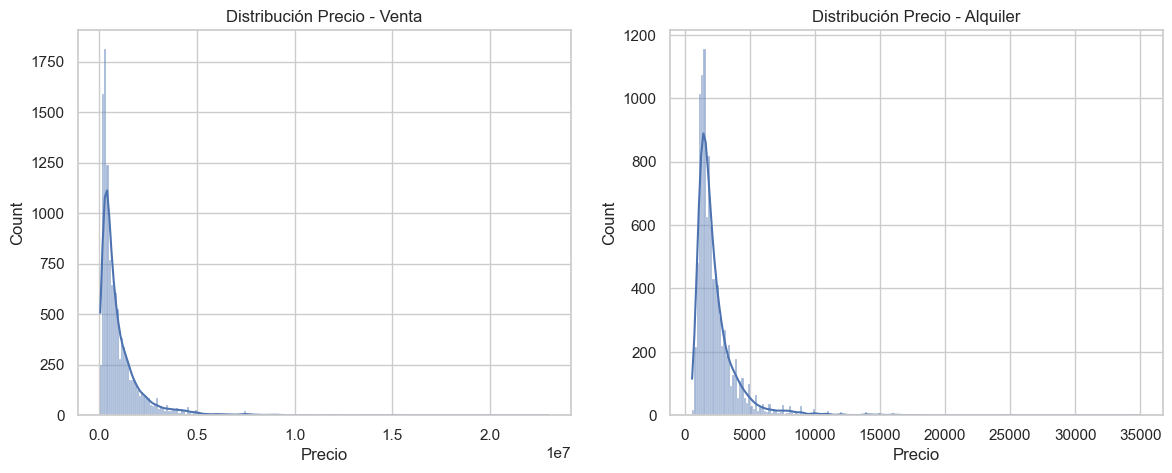

In [47]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(df_venta["Precio"], kde=True, ax=axes[0])
axes[0].set_title("Distribución Precio - Venta")

sns.histplot(df_alquiler["Precio"], kde=True, ax=axes[1])
axes[1].set_title("Distribución Precio - Alquiler")

plt.show()

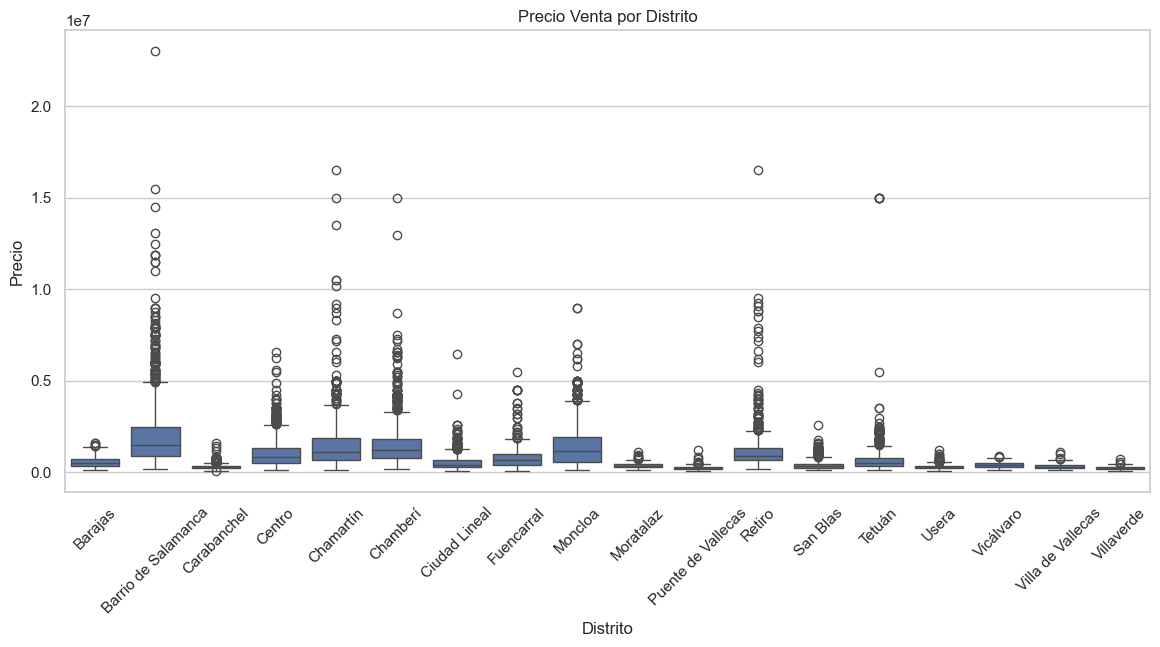

In [20]:
top_barrios = df_venta["Distrito"].value_counts().index

plt.figure(figsize=(14,6))
sns.boxplot(data=df_venta[df_venta["Distrito"].isin(top_barrios)],
            x="Distrito", y="Precio")

plt.xticks(rotation=45)
plt.title("Precio Venta por Distrito")
plt.show()

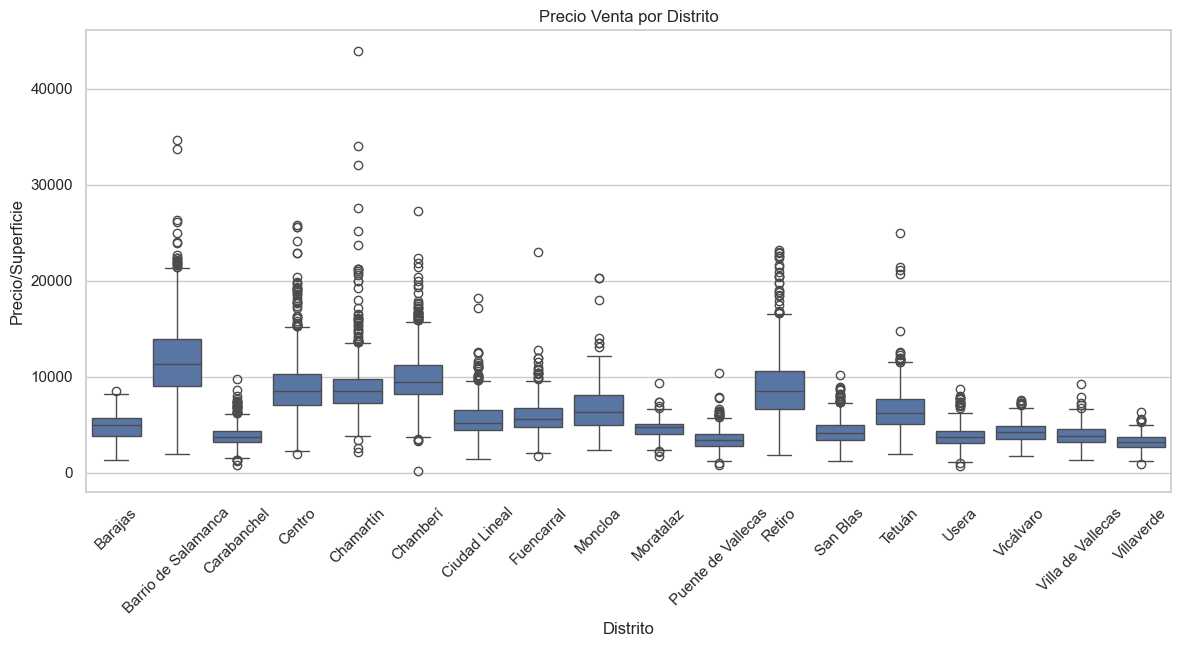

In [48]:
top_barrios = df_venta["Distrito"].value_counts().index

plt.figure(figsize=(14,6))
sns.boxplot(data=df_venta[df_venta["Distrito"].isin(top_barrios)],
            x="Distrito", y="Precio/Superficie")

plt.xticks(rotation=45)
plt.title("Precio Venta por Distrito")
plt.show()

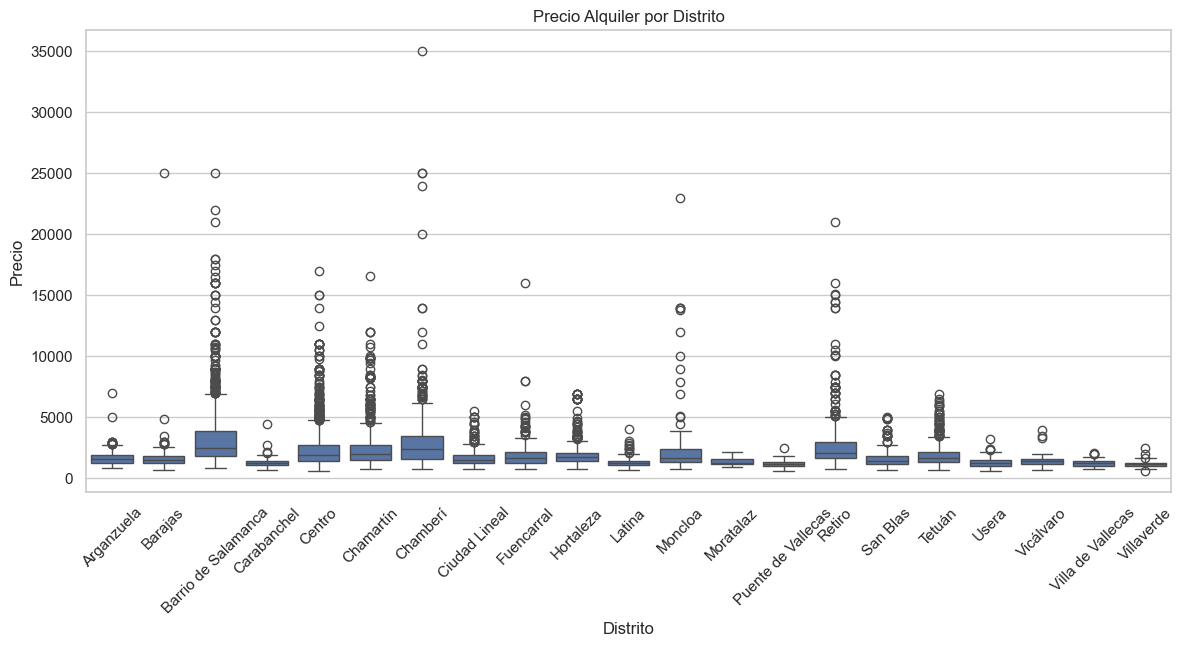

In [21]:
top_barrios = df_alquiler["Distrito"].value_counts().index

plt.figure(figsize=(14,6))
sns.boxplot(data=df_alquiler[df_alquiler["Distrito"].isin(top_barrios)],
            x="Distrito", y="Precio")

plt.xticks(rotation=45)
plt.title("Precio Alquiler por Distrito")
plt.show()

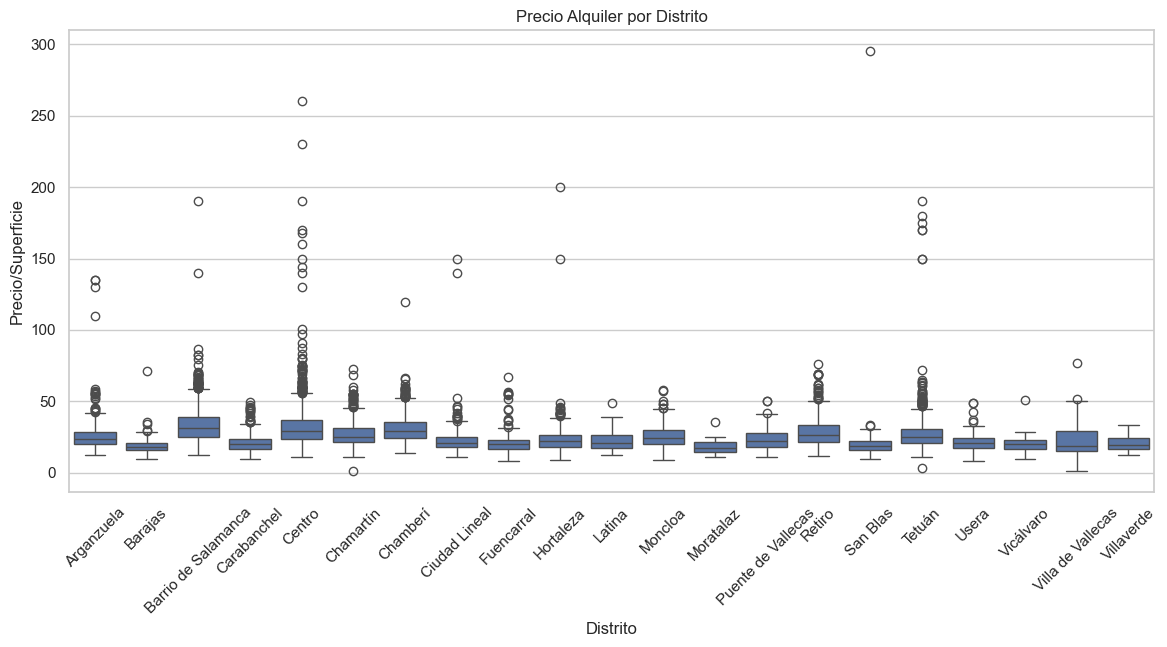

In [49]:
top_barrios = df_alquiler["Distrito"].value_counts().index

plt.figure(figsize=(14,6))
sns.boxplot(data=df_alquiler[df_alquiler["Distrito"].isin(top_barrios)],
            x="Distrito", y="Precio/Superficie")

plt.xticks(rotation=45)
plt.title("Precio Alquiler por Distrito")
plt.show()

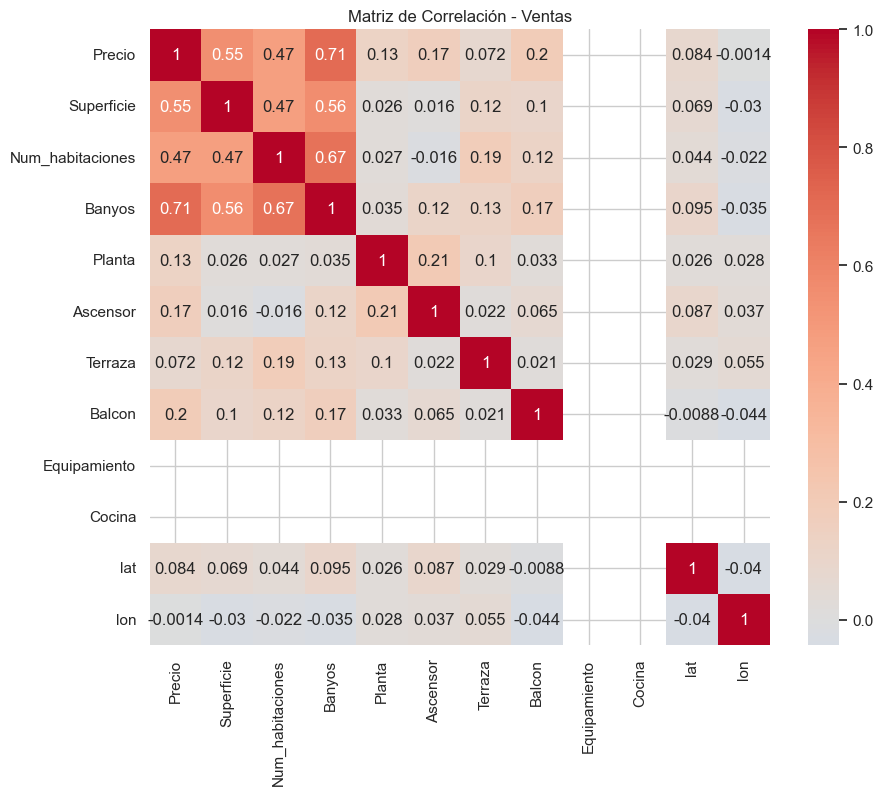

In [ ]:
corr_ventas = df_venta.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_ventas, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlación - Ventas")
plt.show()

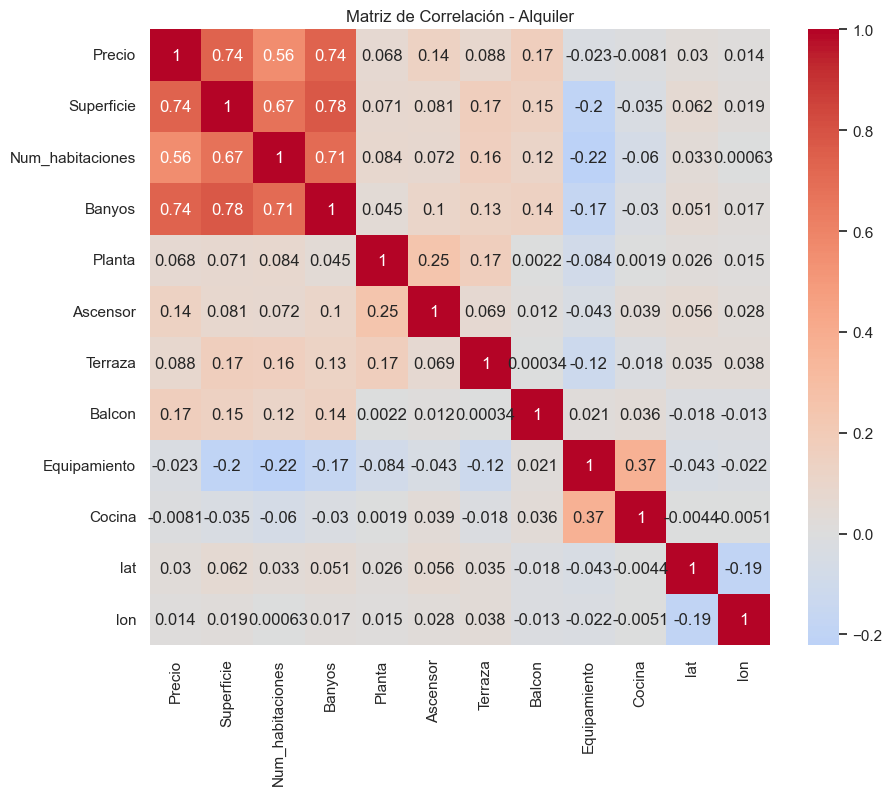

In [ ]:
corr_alquiler = df_alquiler.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr_alquiler, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlación - Alquiler")
plt.show()

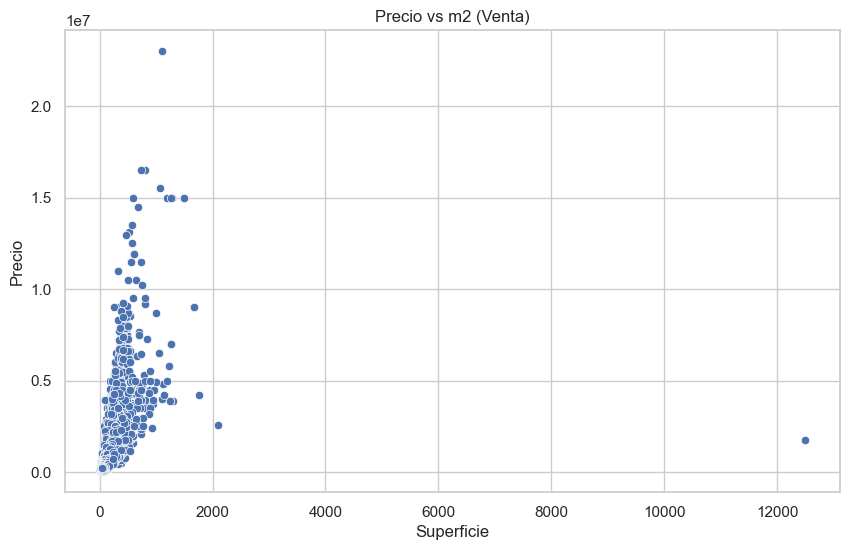

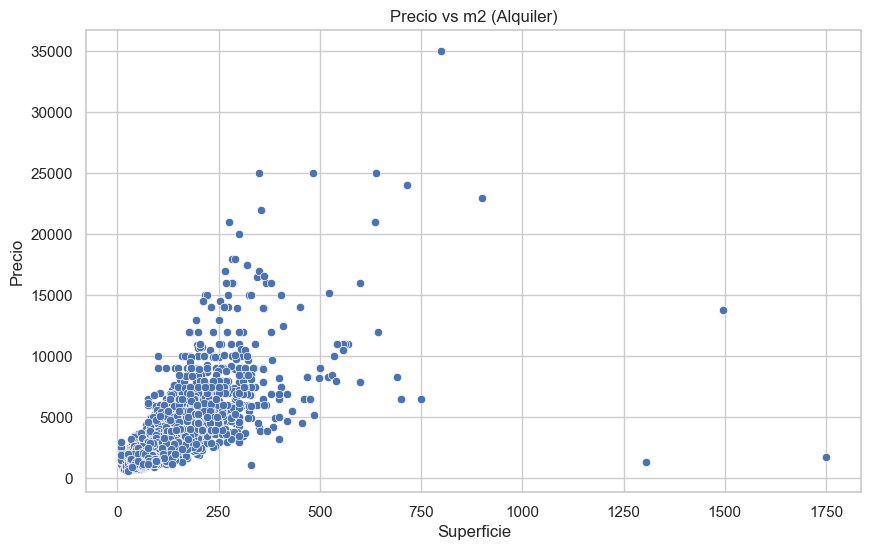

In [36]:
sns.scatterplot(data=df_venta, x="Superficie", y="Precio")
plt.title("Precio vs m2 (Venta)")
plt.show()

sns.scatterplot(data=df_alquiler, x="Superficie", y="Precio")
plt.title("Precio vs m2 (Alquiler)")
plt.show()

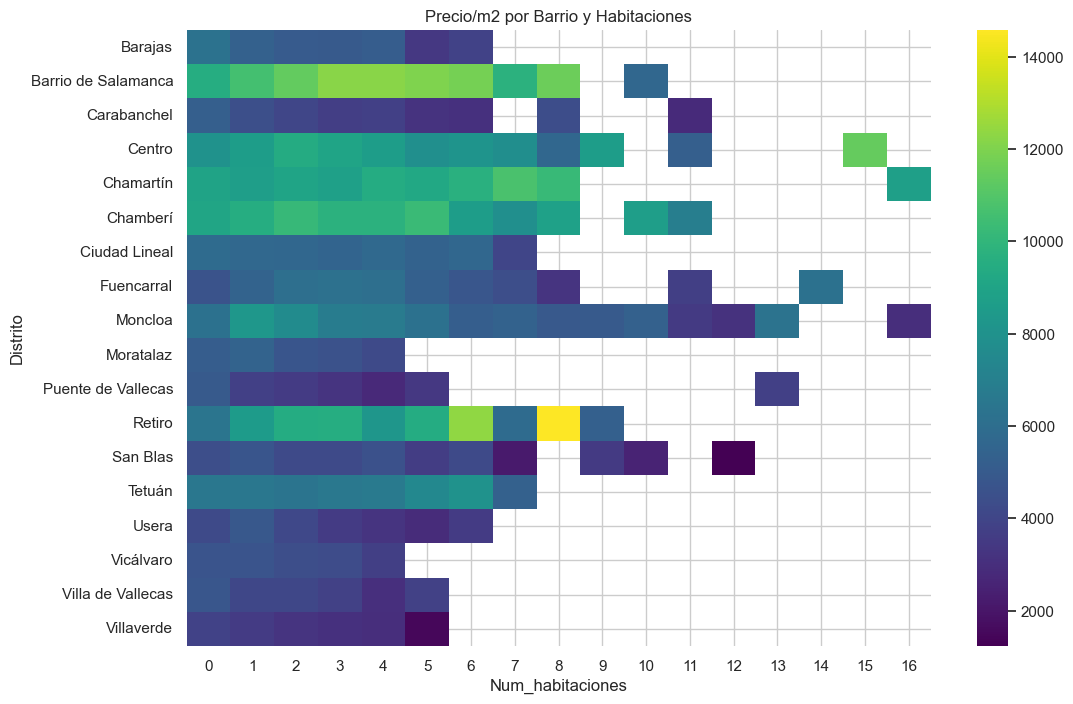

In [40]:
tabla = df_venta.pivot_table(values="Precio/Superficie",
                            index="Distrito",
                            columns="Num_habitaciones",
                            aggfunc="mean")

plt.figure(figsize=(12,8))
sns.heatmap(tabla, cmap="viridis")
plt.title("Precio/m2 por Barrio y Habitaciones")
plt.show()

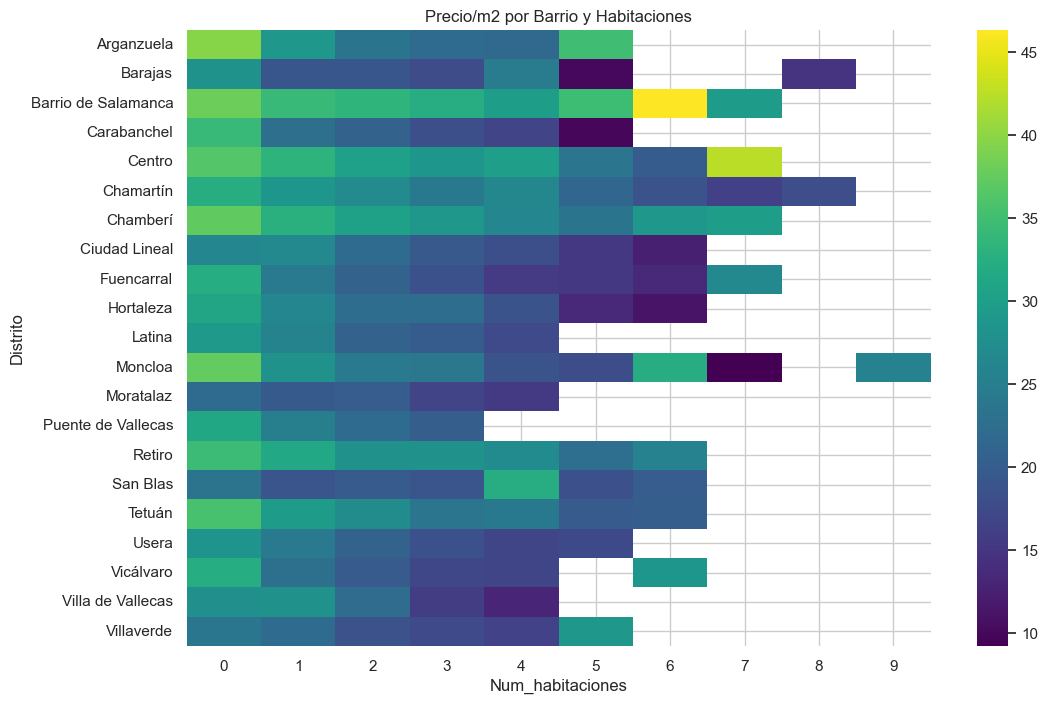

In [41]:
tabla = df_alquiler.pivot_table(values="Precio/Superficie",
                            index="Distrito",
                            columns="Num_habitaciones",
                            aggfunc="mean")

plt.figure(figsize=(12,8))
sns.heatmap(tabla, cmap="viridis")
plt.title("Precio/m2 por Barrio y Habitaciones")
plt.show()

In [43]:
Q1 = df_venta["Precio/Superficie"].quantile(0.25)
Q3 = df_venta["Precio/Superficie"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

outliers = df_venta[df_venta["Precio/Superficie"] > limite_superior]

print("Número de outliers:", len(outliers))

Número de outliers: 251


In [44]:
Q1 = df_alquiler["Precio/Superficie"].quantile(0.25)
Q3 = df_alquiler["Precio/Superficie"].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR

outliers = df_alquiler[df_alquiler["Precio/Superficie"] > limite_superior]

print("Número de outliers:", len(outliers))

Número de outliers: 316


In [45]:
stat, p = stats.shapiro(df_venta["Precio/Superficie"].sample(500))

print("Shapiro-Wilk p-value:", p)

Shapiro-Wilk p-value: 2.759006448804006e-17


In [46]:
stat, p = stats.shapiro(df_alquiler["Precio/Superficie"].sample(500))

print("Shapiro-Wilk p-value:", p)

Shapiro-Wilk p-value: 6.300739134680567e-17
